In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
import cv2
%matplotlib inline

# PyTorch core
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# TorchVision
import torchvision.transforms.v2 as v2
from torchvision.models import resnet50, densenet121, ResNet50_Weights, DenseNet121_Weights
from torchvision.utils import make_grid

# Data utilities
from torch.utils.data.dataloader import DataLoader
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split
from tqdm import tqdm

# Evaluation
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)


cuda


In [2]:
MAIN_PATH = r"C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\Deep Learning\CNN\All Data About CNN\Face-Age-Gender Dataset\face_dataset"
TRAIN_PATH = os.path.join(MAIN_PATH,"train")
TEST_PATH = os.path.join(MAIN_PATH,"test")

IMG_SIZE = 224

EPOCHS = 10
BATCH_SIZE = 64
PATIENCE = 5

LR = 1e-5

MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

NUM_WORKERS = 0

In [3]:
class CustomDataset(Dataset):
    def __init__(self, csv_file, transform=None):
        self.data = csv_file
        self.transform = transform
        
        # Encode labels
        unique_labels = sorted(self.data.iloc[:, 1].unique())
        self.label2idx = {label: idx for idx, label in enumerate(unique_labels)}
        # {'18-20': 0, '21-30': 1, '31-40': 2, '41-50': 3, '51-60': 4}

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        img_path = self.data.iloc[index, 0]
        label = self.data.iloc[index, 1]

        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        return image, self.label2idx[label]

In [4]:
# class FocalLoss(nn.Module):

#     def __init__(self, alpha=1, gamma=2, reduction='mean'):
#         super().__init__()

#         self.alpha = alpha
#         self.gamma = gamma
#         self.reduction = reduction

#     def forward(self, inputs, targets):

#         ce_loss = F.cross_entropy(
#             inputs,
#             targets,
#             reduction='none'
#         )

#         pt = torch.exp(-ce_loss)

#         focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss

#         if self.reduction == 'mean':
#             return focal_loss.mean()

#         elif self.reduction == 'sum':
#             return focal_loss.sum()

#         else:
#             return focal_loss

In [5]:
small_df = pd.read_csv(r"C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\Deep Learning\CNN\All Data About CNN\Face Age Dataset\age_detection.csv")
train_df = pd.read_csv(os.path.join(MAIN_PATH,"train.csv"))
test_df = pd.read_csv(os.path.join(MAIN_PATH,"test.csv"))
small_df

,file,age,split
0,train/18-20/0.jpg,18-20,train
1,train/18-20/1.jpg,18-20,train
2,train/18-20/2.jpg,18-20,train
3,train/18-20/3.jpg,18-20,train
4,train/18-20/4.jpg,18-20,train
...,...,...,...
145,test/51-60/25.jpg,51-60,test
146,test/51-60/26.jpg,51-60,test
147,test/51-60/27.jpg,51-60,test
148,test/51-60/28.jpg,51-60,test


In [6]:
train_df

,id,full_path,gender,age
0,0,train/00000.jpg,1,66
1,1,train/00001.jpg,1,53
2,2,train/00002.jpg,1,20
3,3,train/00003.jpg,1,32
4,4,train/00004.jpg,1,21
...,...,...,...,...
34703,34703,train/34703.jpg,1,32
34704,34704,train/34704.jpg,1,28
34705,34705,train/34705.jpg,1,25
34706,34706,train/34706.jpg,1,19


In [7]:
test_df

,id,full_path
0,0,test/00000.jpg
1,1,test/00001.jpg
2,2,test/00002.jpg
3,3,test/00003.jpg
4,4,test/00004.jpg
...,...,...
8672,8672,test/08672.jpg
8673,8673,test/08673.jpg
8674,8674,test/08674.jpg
8675,8675,test/08675.jpg


In [8]:
train_df["age"].describe()

count    34708.000000
mean        37.346692
std         16.587891
min          1.000000
25%         25.000000
50%         32.000000
75%         48.000000
max        100.000000
Name: age, dtype: float64

{'whiskers': [<matplotlib.lines.Line2D at 0x28c17494410>,
 'caps': [<matplotlib.lines.Line2D at 0x28c17494690>,
 'boxes': [<matplotlib.lines.Line2D at 0x28c17474190>],
 'medians': [<matplotlib.lines.Line2D at 0x28c17494910>],
 'fliers': [<matplotlib.lines.Line2D at 0x28c17494a50>],
 'means': []}

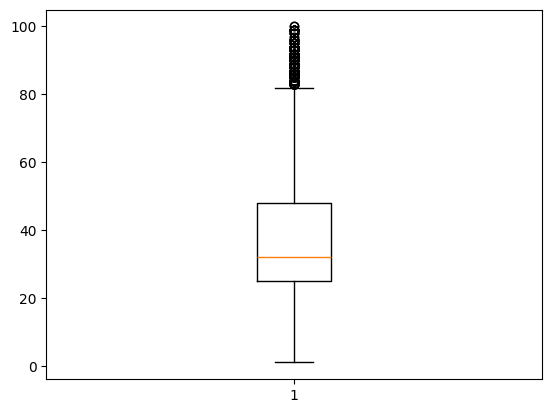

In [9]:
plt.boxplot(train_df['age'])

In [10]:
train_df = train_df[train_df['age'] <= 70][train_df['age'] >= 14]
train_df

C:\Users\ibrah.HIMA\AppData\Local\Temp\ipykernel_22268\981516908.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  train_df = train_df[train_df['age'] <= 70][train_df['age'] >= 14]


,id,full_path,gender,age
0,0,train/00000.jpg,1,66
1,1,train/00001.jpg,1,53
2,2,train/00002.jpg,1,20
3,3,train/00003.jpg,1,32
4,4,train/00004.jpg,1,21
...,...,...,...,...
34703,34703,train/34703.jpg,1,32
34704,34704,train/34704.jpg,1,28
34705,34705,train/34705.jpg,1,25
34706,34706,train/34706.jpg,1,19


{'whiskers': [<matplotlib.lines.Line2D at 0x28c1dc99310>,
 'caps': [<matplotlib.lines.Line2D at 0x28c1dc99590>,
 'boxes': [<matplotlib.lines.Line2D at 0x28c1dc991d0>],
 'medians': [<matplotlib.lines.Line2D at 0x28c1dc99810>],
 'fliers': [<matplotlib.lines.Line2D at 0x28c1dc99950>],
 'means': []}

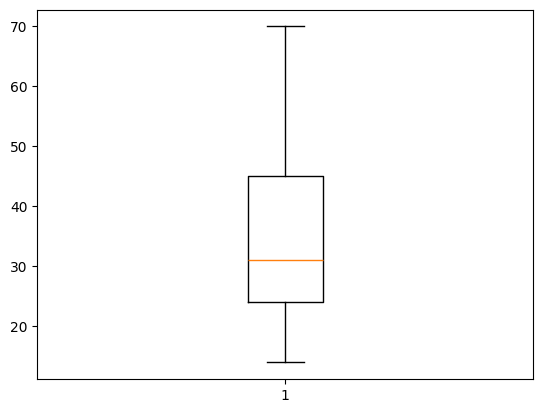

In [11]:
plt.boxplot(train_df['age'])

In [12]:
def set_age_range(x):
    if x in [x for x in range(14 , 25)]:
        return '14-24'
    elif x in [x for x in range(25,41)]:
        return '25-40'
    elif x in [x for x in range(41,71)]:
        return '41-70'


In [13]:
train_df.rename(columns={'full_path': 'file'}, inplace=True)
train_df["age"] = train_df["age"].apply(lambda x: set_age_range(x))
train_df["file"] = train_df["file"].apply(lambda x: os.path.join(MAIN_PATH,x))
train_df.drop(['id','gender'],axis=1,inplace=True)
train_df.reset_index(drop=True,inplace=True)
train_df

,file,age
0,C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\D...,41-70
1,C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\D...,41-70
2,C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\D...,14-24
3,C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\D...,25-40
4,C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\D...,14-24
...,...,...
32803,C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\D...,25-40
32804,C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\D...,25-40
32805,C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\D...,25-40
32806,C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\D...,14-24


In [14]:
train_df['age'].value_counts()

age
25-40    13931
41-70    10420
14-24     8457
Name: count, dtype: int64

In [36]:
labels = set(train_df["age"].values)
labels = sorted(list(labels))
labels

['14-24', '25-40', '41-70']

In [16]:
# small_df["file"] = small_df["file"].apply(lambda x: os.path.join(r"C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\Deep Learning\CNN\All Data About CNN\Face Age Dataset",x))
# small_df.drop('split',axis=1,inplace=True)
# small_df.reset_index(drop=True,inplace=True)
# small_df

In [17]:
# small_df['age'].value_counts()

In [18]:
# full_train_df = pd.concat([train_df,small_df],axis=0,)
# full_train_df

In [19]:
# train_df['age'] = train_df['age'].replace('18-20', '10-20')

In [20]:
train_df['age'].value_counts()

age
25-40    13931
41-70    10420
14-24     8457
Name: count, dtype: int64

2
(500, 500)
3


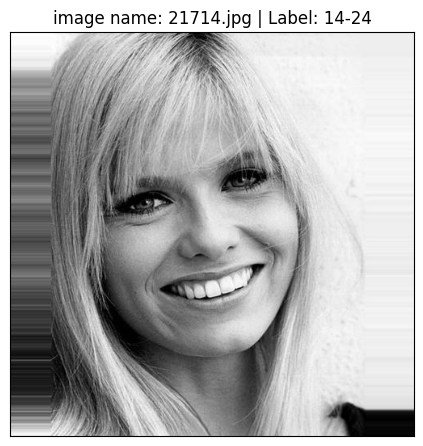

In [21]:
def show_img():
    img_path = np.random.choice(train_df[train_df['age'] == '14-24']["file"].values)
    img = plt.imread(os.path.join(MAIN_PATH,img_path))
    print(img.ndim)
    print(img.shape)
    if img.ndim == 2:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        print(img.ndim)
    plt.imshow(img)
    plt.title(f"image name: {img_path.split('/')[-1]} | Label: {train_df[train_df['file']== img_path]['age'].values[0]}")
    plt.tight_layout()
    plt.yticks([])
    plt.xticks([])
    plt.show()

show_img()

In [22]:
def get_transforms(size=IMG_SIZE, apply_on_train=False):
    """
    Return a transform pipeline for the given split.

    Parameters
    ----------
    size           : int  — target image size (default 224)
    apply_on_train : bool — whether to include data augmentation
    """
    base = [
        v2.Resize((size, size)),
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
    ]

    augmentation = [
        v2.RandomHorizontalFlip(),
        v2.RandomRotation(20),
        v2.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
        # v2.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    ]

    tail = [
        v2.Normalize(MEAN, STD),
    ]

    if apply_on_train:
        return v2.Compose(base + augmentation + tail)
    return v2.Compose(base + tail)


In [23]:
train, temp_df = train_test_split(train_df, test_size=0.2, 
                                      random_state=42)
val, test   = train_test_split(temp_df, test_size=0.5, 
                                      random_state=42)

print(f"Train Length is => {len(train)}")
print(f"val Length is => {len(val)}")
print(f"test Length is => {len(test)}")
print(f"Total = {len(train) + len(val) + len(test)}")

Train Length is => 26246
val Length is => 3281
test Length is => 3281
Total = 32808


In [24]:
train_ds = CustomDataset(train, get_transforms(IMG_SIZE, True))
val_ds   = CustomDataset(val, get_transforms(IMG_SIZE))
test_ds  = CustomDataset(test, get_transforms(IMG_SIZE))

In [25]:
train_ds.transform

Compose(
      Resize(size=[224, 224], interpolation=InterpolationMode.BILINEAR, antialias=True)
      ToImage()
      ToDtype(scale=True)
      RandomHorizontalFlip(p=0.5)
      RandomRotation(degrees=[-20.0, 20.0], interpolation=InterpolationMode.NEAREST, expand=False, fill=0)
      ColorJitter(brightness=(0.7, 1.3), contrast=(0.7, 1.3), saturation=(0.8, 1.2))
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)
)

In [26]:
val_ds.transform

Compose(
      Resize(size=[224, 224], interpolation=InterpolationMode.BILINEAR, antialias=True)
      ToImage()
      ToDtype(scale=True)
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)
)

In [27]:
test_ds.transform

Compose(
      Resize(size=[224, 224], interpolation=InterpolationMode.BILINEAR, antialias=True)
      ToImage()
      ToDtype(scale=True)
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)
)

In [28]:
train_dl = DataLoader(train_ds,BATCH_SIZE,True,num_workers=NUM_WORKERS,pin_memory=False)
val_dl = DataLoader(val_ds,BATCH_SIZE,False,num_workers=NUM_WORKERS,pin_memory=False)
test_dl = DataLoader(test_ds,BATCH_SIZE,False,num_workers=NUM_WORKERS,pin_memory=False)

In [29]:
def denorm(imgs):
    mean = torch.tensor(MEAN).view(1, 3, 1, 1).to(imgs.device)
    std = torch.tensor(STD).view(1, 3, 1, 1).to(imgs.device)
    
    if imgs.dim() == 3:
        imgs = imgs.unsqueeze(0)
        
    return imgs * std + mean

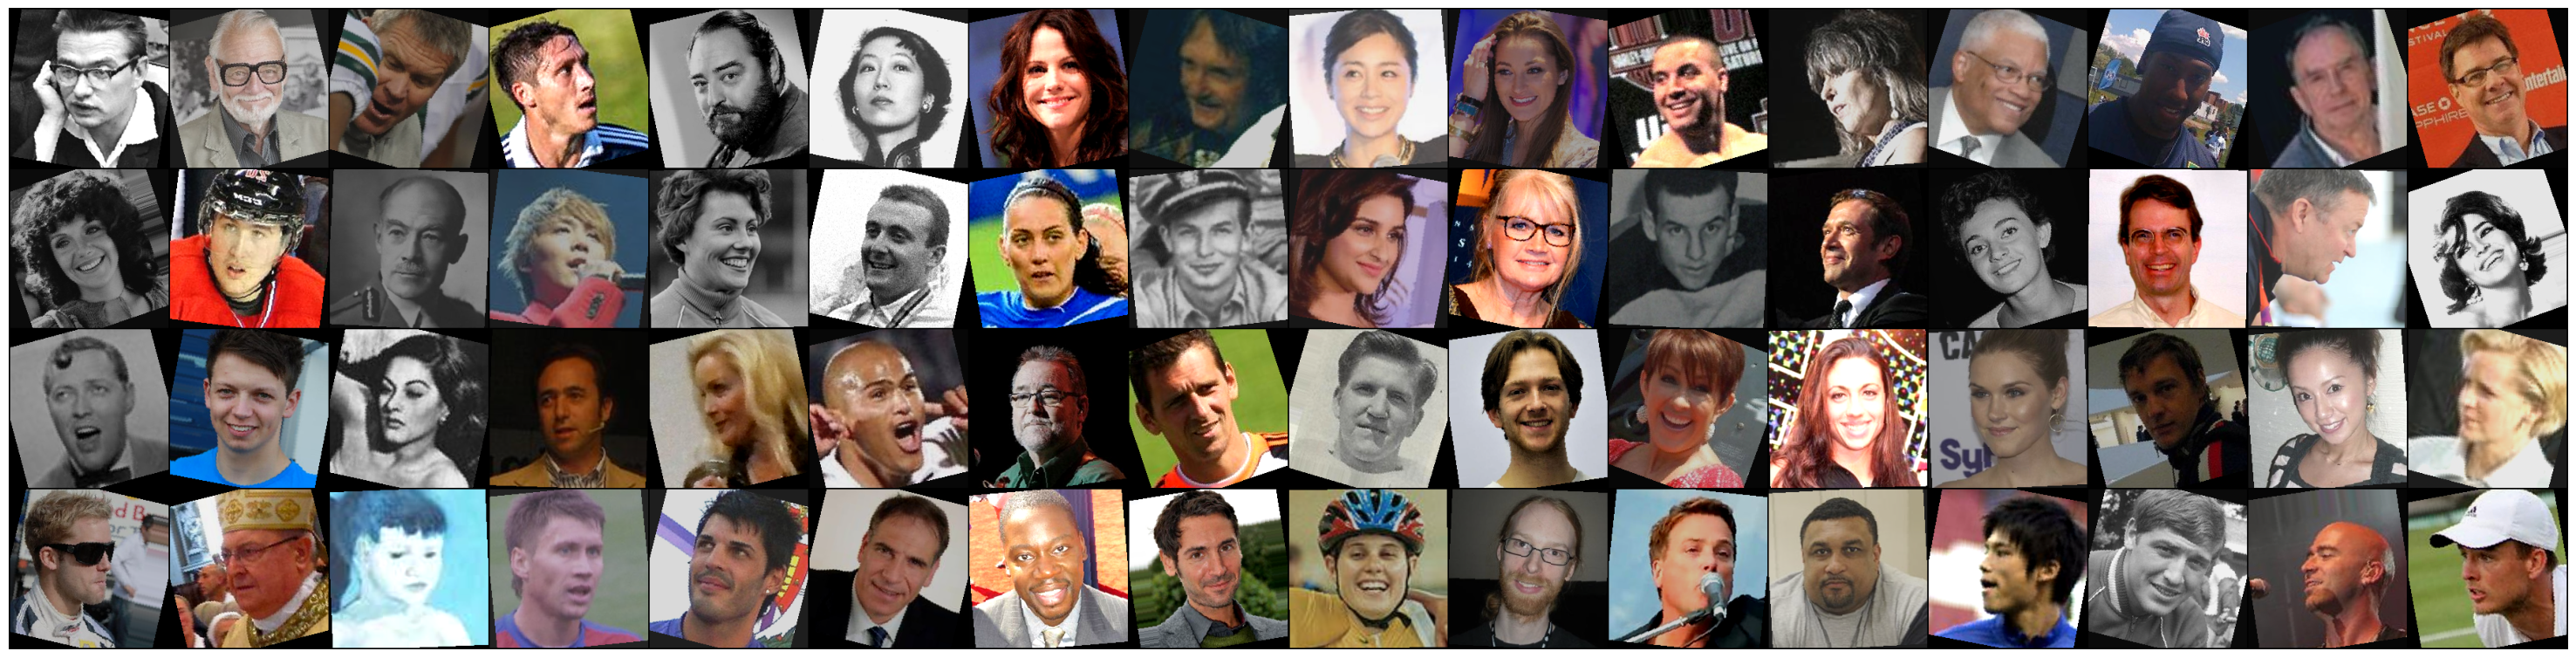

In [30]:
def show_grid_images(dataloader):
    imgs,labels = next(iter(dataloader))
    plt.figure(figsize=(30, 30))
    plt.imshow(make_grid(denorm(imgs),nrow=16).permute(1,2,0))
    plt.tight_layout()
    plt.axis('off')
    plt.show()

show_grid_images(train_dl)

In [ ]:
def replace_classifier(model, name):
    """
    Replace the final classification layer for any supported architecture.

    Supported: DenseNet, ResNet,

    Parameters
    ----------
    model : pretrained PyTorch model
    name  : str — model class name used to identify architecture type

    Returns
    -------
    model with replaced classifier
    """
    if "DenseNet" in name:
        
        model.classifier = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(model.classifier.in_features, 5)
        )

    elif "ResNet" in name:
        model.fc = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(model.fc.in_features, 5)
        )

    return model

In [32]:
Model = densenet121(weights=DenseNet121_Weights.DEFAULT)
Model = replace_classifier(Model,Model.__class__.__name__)
Model = Model.to(device)
optimizer = torch.optim.AdamW(Model.parameters(), lr=LR)
criterion = F.cross_entropy

In [ ]:
def fit(model):
    history = []
    best_loss = float('inf')
    counter = 0
    for epoch in range(EPOCHS):

        train_all_loss=[]
        train_all_acc = []

        model.train()

        for batch in tqdm(train_dl,f"Epoch: {epoch+1}/{EPOCHS}"):
            imgs,labels = batch
            imgs = imgs.to(device)
            labels = labels.to(device)

            outputs = model(imgs)

            loss = criterion(outputs,labels).to(device)

            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            _,preds = torch.max(outputs,dim=1)
            
            train_all_loss.append(loss.detach().cpu().item())
            train_all_acc.append((preds == labels).float().mean().item())

        train_loss = sum(train_all_loss) / len(train_all_loss)
        train_acc = sum(train_all_acc) / len(train_all_acc)

        val_all_loss = []
        val_all_acc = []

        model.eval()
        with torch.no_grad():
            for batch in test_dl:
                imgs,labels = batch
                imgs = imgs.to(device)
                labels = labels.to(device)

                outputs = model(imgs)

                loss = criterion(outputs,labels).to(device)


                _,preds = torch.max(outputs,dim=1)
                

                val_all_loss.append(loss.detach().cpu().item())
                val_all_acc.append((preds == labels).float().mean().item())


        val_loss = sum(val_all_loss) / len(val_all_loss)
        val_acc = sum(val_all_acc) / len(val_all_acc)

        print(f"Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f} | Train Accuracy: {train_acc} - Val Accuracy: {val_acc:.4f}")

        history.append({
            "train_loss": train_loss, 'train_acc' : train_acc,
            "val_loss": val_loss,     "val_acc": val_acc
        })

        # ── Early stopping ──────────────────────────────────────────────────
        if val_loss < best_loss:
            best_loss   = val_loss
            counter    = 0
            torch.save(model.state_dict(), f"Saved Models\\best_{model.__class__.__name__}_model.pth")
            print(f"best model saved")
        else:
            counter += 1
            print(f"No improvement ({counter}/{PATIENCE})")
            if counter >= PATIENCE:
                print("Early stopping triggered.")
                break

    return history

history = fit(Model)

In [ ]:
train_acc = [x["train_acc"] for x in history]
val_acc = [x["val_acc"] for x in history]
train_loss = [x["train_loss"] for x in history]
val_loss = [x["val_loss"] for x in history]

In [ ]:
_, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(train_loss, label="Train",      linewidth=2)
ax[0].plot(val_loss,   label="Validation", linewidth=2, linestyle="--")
ax[0].set_title(f"{Model.__class__.__name__} Loss Over Epochs", fontsize=13, fontweight="bold")
ax[0].set_ylabel("Loss")
ax[0].set_xlabel("Epoch")
ax[0].legend()
ax[0].grid(alpha=0.3)

ax[1].plot(train_acc, label="Train",      linewidth=2)
ax[1].plot(val_acc,   label="Validation", linewidth=2, linestyle="--")
ax[1].set_title(f"{Model.__class__.__name__} Accuracy Over Epochs", fontsize=13, fontweight="bold")
ax[1].set_ylabel("AUC")
ax[1].set_xlabel("Epoch")
ax[1].legend()
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'Results\\{Model.__class__.__name__}_ACCURACY_LOSS_Curves.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
all_labels , all_preds , all_imgs = [] , [], []

Model.eval()
with torch.no_grad():
    for batch in test_dl:
        imgs , labels = batch
        imgs = imgs.to(device)
        labels = labels.to(device)
        outputs = Model(imgs)
        _,preds = torch.max(outputs,dim=1)

        all_imgs.extend(imgs.detach().cpu())
        all_labels.extend(labels.detach().cpu())
        all_preds.extend(preds.detach().cpu())


In [ ]:
def Show_CMwithClassReport(all_labels, all_preds, name):
    """Print classification report and plot confusion matrix."""
    cm = confusion_matrix(np.array(all_labels), np.array(all_preds))

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels,
                yticklabels=labels)
    plt.title(f'{name} Confusion Matrix', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'Results\\{name}_confusion_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(classification_report(all_labels, all_preds, target_names=labels))


In [ ]:
Show_CMwithClassReport(all_labels,all_preds,Model.__class__.__name__)

In [ ]:
# Display 20 test samples with color-coded prediction results
_, ax = plt.subplots(4, 5, figsize=(15, 12))
ax = ax.flatten()

for i in range(20):
    x = np.random.randint(0,200)
    img = denorm(all_imgs[x]) 
    img = img.squeeze()

    img = img.permute(1, 2, 0)
    ax[i].imshow(img)
    
    true_class = labels[all_labels[x]]
    pred_class = labels[all_preds[x]]
    correct = all_labels[x] == all_preds[x]

    ax[i].set_title(
        f"True: {true_class}\nPred: {pred_class}",
        color="green" if correct else "red",
        fontsize=9
    )
    ax[i].axis("off")

plt.suptitle("Test Set Predictions (Green = Correct | Red = Wrong)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()